# 🫒 Pipeline IA — Détourage produit + Génération de background + Affiche publicitaire

**Objectif :** à partir d'une photo produit (n'importe quel background, main incluse), produire automatiquement :
1. Le produit parfaitement détouré (aucune perte de matière/forme)
2. Un background généré, cohérent avec les couleurs/l'ambiance du produit
3. Une composition finale harmonisée (ombres/lumière réalistes)
4. Un texte publicitaire généré (accroche + bénéfices + CTA)
5. **3 affiches** (Instagram 1080×1080, Facebook 1200×630, LinkedIn 1200×627) exportées en **ZIP**

**Un seul notebook, exécuté de haut en bas.** Chaque section = une étape indépendante, avec gestion mémoire GPU explicite (les modèles sont chargés puis libérés étape par étape pour tenir sur un GPU Colab standard T4).

Runtime requis : **Colab avec GPU** (Runtime → Change runtime type → GPU, idéalement A100/L4, T4 fonctionne aussi mais plus lent).


## ⚠️ Notes d'ingénierie importantes (à lire avant de lancer)

**1. Détourage (Étape 1) — Grounding DINO + SAM, pas de fine-tuning.**
Une saillance pure (BiRefNet seul) inclut souvent la main qui tient le produit, car elle segmente "le sujet principal photographié" sans distinction de classe. Le pipeline utilise donc **Grounding DINO** (détection d'objet pilotée par texte, ex: `"bottle. jar. tube."`) pour localiser précisément le produit — la main n'étant pas décrite par le texte, elle est exclue par construction — puis **SAM** pour une segmentation fine dans cette boîte. BiRefNet reste comme filet de sécurité si rien n'est détecté. **Toujours zéro fine-tuning** : ces 3 modèles sont utilisés pré-entraînés (zero-shot), et fine-tuner un decoder de segmentation nécessiterait de toute façon des **masques de vérité terrain** que ton dataset ne contient pas.

**2. Génération de background (Étape 3) — text2img + art-direction, pas d'inpainting sur canvas noir.**
Un bug de compositing (canvas transparent converti en RGB = noir, utilisé comme conditionnement du modèle) causait des backgrounds plats et sombres. La correction : génération **text2img** complète de la scène (liberté créative totale) + composition du produit après coup, pilotée par un système catégorie/saison/palette pour des accessoires cohérents (marbre, soie, fleurs, fruits...). **Pas de fine-tuning nécessaire** — c'était un bug de pipeline, pas une limite du modèle. Le LoRA reste en section bonus, à tenter seulement si le temps le permet et que tu veux aller plus loin que le prompt engineering.

**3. Gestion mémoire GPU.**
Grounding DINO + SAM + BiRefNet + SDXL + un LLM 7B ne tiennent pas tous en même temps sur un T4 (16 Go). Le notebook charge/décharge les modèles **séquentiellement** (`del model; torch.cuda.empty_cache()`) entre chaque étape lors du traitement du dataset complet. Pour l'intégration finale dans ton backend FastAPI, tu chargeras les modèles une seule fois au démarrage du serveur (voir section finale).

**4. Priorité 48h.** Si tu manques de temps : Étapes 1 (détourage robuste), 2, 3 (sans LoRA), 4 (harmonisation simple), 5 (texte avec fallback template), 6 (composition) = pipeline complet fonctionnel. Les sections marquées **BONUS** sont sacrifiables sans casser le rendu final.


## 0. Setup — Drive, GPU, dossiers de travail

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import torch
print("GPU disponible :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    print("VRAM totale :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "Go")


Mounted at /content/drive
GPU disponible : True
GPU : Tesla T4
VRAM totale : 15.6 Go


In [ ]:
# Installation des dependances (open source uniquement)
# Pin numpy/scipy explicitement -- evite le conflit ABI classique sur Colab
# ("cannot import name '_center' from numpy._core.umath") quand un package
# tiers (diffusers/transformers/accelerate) upgrade numpy en cours de session.
!pip uninstall -y -q numpy scipy
!pip install -q --no-cache-dir numpy==1.26.4 scipy==1.13.1
!pip install -q diffusers==0.30.0 transformers==4.44.0 accelerate==0.33.0 peft==0.12.0
!pip install -q safetensors huggingface_hub opencv-python-headless scikit-learn
!pip install -q bitsandbytes  # pour charger le LLM en 4-bit
!pip install -q kornia  # utilitaires image (harmonisation)

print("Installation terminee -- redemarrage du runtime dans 3s (necessaire pour appliquer numpy/scipy proprement)")
import time
time.sleep(3)
import os, signal
os.kill(os.getpid(), signal.SIGKILL)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 34.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 211.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 281.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 275.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.


**⚠️ Le message "La session s'est arrêtée de manière inattendue" qui va apparaître ici est normal et voulu** — c'est un redémarrage forcé du runtime pour que numpy/scipy soient proprement rechargés (sans ça, `transformers` plante avec une erreur `ImportError: cannot import name '_center'`). **Continue directement à la cellule suivante** — pas besoin de relancer cette cellule d'installation, elle a déjà fait son travail.


In [5]:
import os, glob, shutil, zipfile, json, random
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont, ImageFilter, ImageOps
import numpy as np
import cv2

# ---- CONFIG : adapte si besoin ----
DATASET_DIR = "/content/drive/MyDrive/Stage_1_ouvrier/data/raw/dataset_augmented"
WORK_DIR    = "/content/drive/MyDrive/Stage_1_ouvrier/data/processed"
CUTOUTS_DIR = os.path.join(WORK_DIR, "cutouts")       # produits detoures (RGBA)
MASKS_DIR   = os.path.join(WORK_DIR, "masks")         # masques alpha
BG_DIR      = os.path.join(WORK_DIR, "backgrounds")   # backgrounds generes
FINAL_DIR   = os.path.join(WORK_DIR, "final_posters")
ZIP_DIR     = os.path.join(WORK_DIR, "zips")

for d in [WORK_DIR, CUTOUTS_DIR, MASKS_DIR, BG_DIR, FINAL_DIR, ZIP_DIR]:
    os.makedirs(d, exist_ok=True)

image_paths = sorted(glob.glob(os.path.join(DATASET_DIR, "**", "*.[jJpP][pPnN]*[gG]"), recursive=True))
print(f"{len(image_paths)} images trouvees dans {DATASET_DIR}")
assert len(image_paths) > 0, "Aucune image trouvee -- verifie DATASET_DIR"


600 images trouvees dans /content/drive/MyDrive/Stage_1_ouvrier/data/raw/dataset_augmented


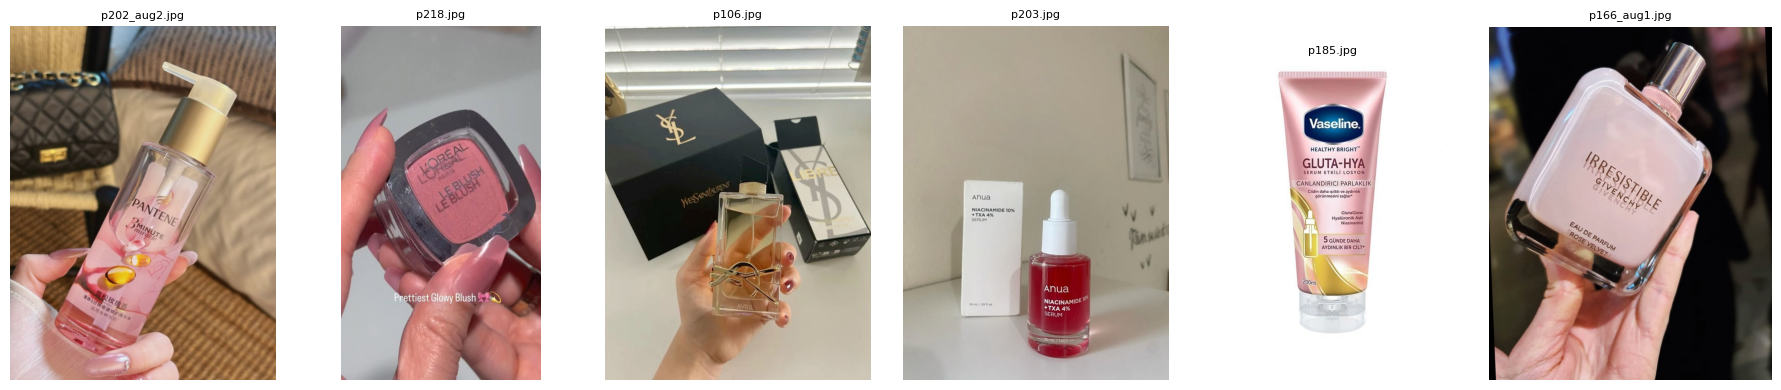

In [2]:
# Apercu rapide du dataset
import matplotlib.pyplot as plt

sample = random.sample(image_paths, min(6, len(image_paths)))
fig, axes = plt.subplots(1, len(sample), figsize=(18, 4))
for ax, p in zip(axes, sample):
    ax.imshow(Image.open(p).convert("RGB"))
    ax.set_title(Path(p).name, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 0-ter. Filtrage qualité + complément par augmentation (idempotent)

But : écarter les photos trop floues/bruitées du dataset brut, puis compléter par des augmentations légères (flip, rotation, zoom, luminosité) pour revenir exactement à `TARGET_TOTAL` images.

**⚠️ Important — bug corrigé ici :** exécuter une cellule d'augmentation plusieurs fois (nouvelle session, relance manuelle) sans jamais vider `AUGMENTED_DIR` fait **s'accumuler** des fichiers d'un run à l'autre — c'est exactement ce qui t'a fait dépasser 600 images. La version ci-dessous est **idempotente** : elle **vide et regénère entièrement** `AUGMENTED_DIR` à chaque exécution, avec une graine aléatoire fixe (`random.seed(42)`). Résultat : peu importe combien de fois tu relances cette cellule (même dans un autre compte), tu obtiens toujours exactement `TARGET_TOTAL` images, ni plus ni moins.


In [17]:
def compute_blur_score(pil_image):
    gray = cv2.cvtColor(np.array(pil_image.convert("RGB")), cv2.COLOR_RGB2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()  # bas = flou

def compute_noise_score(pil_image):
    gray = cv2.cvtColor(np.array(pil_image.convert("RGB")), cv2.COLOR_RGB2GRAY).astype(np.float32)
    denoised = cv2.medianBlur(gray.astype(np.uint8), 5).astype(np.float32)
    return (gray - denoised).std()  # haut = bruite

BLUR_THRESHOLD = 100   # en dessous = trop flou -- ajuste apres avoir regarde l'histogramme ci-dessous
NOISE_THRESHOLD = 15   # au dessus = trop bruite

quality_scores = []
for p in image_paths:
    img = Image.open(p).convert("RGB")
    quality_scores.append({
        "path": p, "name": Path(p).stem,
        "blur": compute_blur_score(img),
        "noise": compute_noise_score(img),
    })

blur_vals = [q["blur"] for q in quality_scores]
noise_vals = [q["noise"] for q in quality_scores]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(blur_vals, bins=40); axes[0].axvline(BLUR_THRESHOLD, color="red"); axes[0].set_title("Nettete (bas = flou)")
axes[1].hist(noise_vals, bins=40); axes[1].axvline(NOISE_THRESHOLD, color="red"); axes[1].set_title("Bruit (haut = bruite)")
plt.show()

clean_original_paths = sorted([
    q["path"] for q in quality_scores
    if q["blur"] >= BLUR_THRESHOLD and q["noise"] <= NOISE_THRESHOLD
])
print(f"{len(quality_scores) - len(clean_original_paths)} images rejetees (floues/bruitees) sur {len(quality_scores)}")
print(f"{len(clean_original_paths)} images originales propres conservees")


KeyboardInterrupt: 

In [4]:
# Regeneration idempotente de AUGMENTED_DIR -- vide et recree a chaque execution,
# graine fixe -> resultat identique et stable peu importe le nombre de relances.
from PIL import ImageEnhance

TARGET_TOTAL = 600
AUGMENTED_DIR = os.path.join(WORK_DIR, "augmented_clean")

if os.path.isdir(AUGMENTED_DIR):
    shutil.rmtree(AUGMENTED_DIR)
os.makedirs(AUGMENTED_DIR, exist_ok=True)

random.seed(42)  # reproductibilite -- meme resultat a chaque relance

n_needed = max(0, TARGET_TOTAL - len(clean_original_paths))
print(f"{len(clean_original_paths)} images propres, {n_needed} augmentations necessaires pour atteindre {TARGET_TOTAL}")

def augment_once(pil_image):
    img = pil_image.convert("RGB")
    if random.random() < 0.5:
        img = ImageOps.mirror(img)
    angle = random.uniform(-10, 10)
    img = img.rotate(angle, resample=Image.BICUBIC, expand=False, fillcolor=(255, 255, 255))
    zoom = random.uniform(0.85, 0.95)
    w, h = img.size
    new_w, new_h = int(w * zoom), int(h * zoom)
    left = random.randint(0, w - new_w)
    top = random.randint(0, h - new_h)
    img = img.crop((left, top, left + new_w, top + new_h)).resize((w, h), Image.LANCZOS)
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.9, 1.1))
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.9, 1.1))
    return img

augmented_paths = []
source_pool = clean_original_paths.copy()
random.shuffle(source_pool)
attempts, max_attempts = 0, n_needed * 5

while len(augmented_paths) < n_needed and attempts < max_attempts and len(source_pool) > 0:
    src_path = source_pool[attempts % len(source_pool)]
    aug_img = augment_once(Image.open(src_path).convert("RGB"))
    if compute_blur_score(aug_img) >= BLUR_THRESHOLD and compute_noise_score(aug_img) <= NOISE_THRESHOLD:
        name = f"{Path(src_path).stem}_aug{len(augmented_paths):04d}.png"
        out_path = os.path.join(AUGMENTED_DIR, name)
        aug_img.save(out_path)
        augmented_paths.append(out_path)
    attempts += 1

# Dataset final -- toujours exactement clean_originals + augmentations, plafonne a TARGET_TOTAL
image_paths = sorted(clean_original_paths) + sorted(augmented_paths)

print(f"{len(augmented_paths)} images augmentees generees -> {AUGMENTED_DIR}")
print(f"Dataset final : {len(image_paths)} images (cible : {TARGET_TOTAL})")
assert len(image_paths) <= TARGET_TOTAL, "Ne devrait jamais depasser TARGET_TOTAL -- verifie la logique ci-dessus"


330 images propres, 270 augmentations necessaires pour atteindre 600
270 images augmentees generees -> /content/drive/MyDrive/Stage_1_ouvrier/data/processed/augmented_clean
Dataset final : 600 images (cible : 600)


In [18]:
# Diagnostic -- verite terrain sur ce qui existe reellement sur Drive, a lancer a tout moment
def count_files(dir_path, pattern="*"):
    return len(glob.glob(os.path.join(dir_path, pattern))) if os.path.isdir(dir_path) else 0

print("=== Etat reel des dossiers sur Drive ===")
print(f"Dataset brut ({DATASET_DIR}) : {count_files(DATASET_DIR, '**/*.*')} fichiers (recursif)")
print(f"Images propres apres filtrage qualite : {len(clean_original_paths)}")
print(f"Augmented_clean (regenere ce run)     : {count_files(AUGMENTED_DIR, '*.png')}")
print(f"image_paths (dataset final en memoire) : {len(image_paths)}")
print(f"Cutouts deja detoures                  : {count_files(CUTOUTS_DIR, '*.png')}")
print(f"Masks deja generes                     : {count_files(MASKS_DIR, '*.png')}")


=== Etat reel des dossiers sur Drive ===
Dataset brut (/content/drive/MyDrive/Stage_1_ouvrier/data/raw/dataset_augmented) : 0 fichiers (recursif)


NameError: name 'clean_original_paths' is not defined

## 0-bis. Reprise après coupure GPU (checkpoint) — IMPORTANT

Colab peut couper la session à tout moment (quota GPU épuisé, inactivité, changement de compte). **Rien de ce qui est en mémoire ne survit à une coupure** — seuls les fichiers écrits sur Drive persistent. La stratégie ci-dessous protège toute boucle longue (détourage des 600 images, génération en masse, etc.) :

- Après **chaque élément traité**, son identifiant est ajouté à un fichier `checkpoint_*.json` sur Drive.
- Au redémarrage — même dans un **autre compte Google**, tant que ce compte a accès au **même dossier Drive** — la boucle relit ce fichier et **saute tout ce qui est déjà fait**.

**Pour que ça marche en changeant de compte (`zaraiimen86@gmail.com` ↔ ton autre compte) :**
1. Depuis le compte propriétaire actuel du dossier `Stage_1_ouvrier`, clic droit sur le dossier → **Partager** → ajoute l'autre adresse Gmail en accès **Éditeur**.
2. Depuis l'autre compte, va dans **"Partagés avec moi"**, clic droit sur `Stage_1_ouvrier` → **"Organiser" → "Ajouter un raccourci à Mon Drive"**.
3. Résultat : le chemin `/content/drive/MyDrive/Stage_1_ouvrier/...` pointe vers **le même dossier physique** sur les deux comptes. Sans cette étape, `MyDrive` sur le nouveau compte est vide et le chemin n'existera pas.

**Procédure de reprise après coupure :**
1. Ouvre le notebook (depuis Drive, ou re-upload le `.ipynb`) sur le compte GPU disponible.
2. Réexécute les cellules de **Setup** (mount Drive, installs, chargement du modèle de l'étape en cours) — rapide (~2-5 min), c'est normal de les refaire à chaque nouvelle session.
3. Relance directement la cellule de boucle (détourage, génération, etc.) — elle détecte automatiquement le checkpoint et reprend là où ça s'est arrêté, sans retraiter ce qui est déjà fait.


In [19]:
# Utilitaire generique de checkpoint / reprise -- reutilise pour toute boucle longue du notebook

def load_checkpoint(checkpoint_path):
    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, "r") as f:
            return set(json.load(f))
    return set()

def save_checkpoint(checkpoint_path, done_set):
    tmp_path = checkpoint_path + ".tmp"
    with open(tmp_path, "w") as f:
        json.dump(sorted(done_set), f)
    os.replace(tmp_path, checkpoint_path)  # ecriture atomique, evite un fichier corrompu si coupure pendant l'ecriture


def run_resumable_batch(items, key_fn, process_fn, checkpoint_path, save_every=5, label="batch"):
    # items      : liste d'elements a traiter
    # key_fn     : fonction qui extrait un identifiant unique et stable par element (ex: nom de fichier)
    # process_fn : fonction qui traite un element (effets de bord : sauvegarde sur disque)
    # checkpoint_path : chemin JSON sur Drive ou la progression est stockee
    done = load_checkpoint(checkpoint_path)
    remaining = [it for it in items if key_fn(it) not in done]
    print(f"[{label}] {len(done)} deja traites (checkpoint trouve), {len(remaining)} restants sur {len(items)}")

    since_last_save = 0
    for i, item in enumerate(remaining):
        key = key_fn(item)
        try:
            process_fn(item)
            done.add(key)
        except Exception as e:
            print(f"[{label}] Erreur sur {key}: {e}")
            continue

        since_last_save += 1
        if since_last_save >= save_every:
            save_checkpoint(checkpoint_path, done)
            since_last_save = 0
            print(f"[{label}] checkpoint sauvegarde -- {len(done)}/{len(items)}")

    save_checkpoint(checkpoint_path, done)
    print(f"[{label}] termine -- {len(done)}/{len(items)} traites au total")


## 1. Détourage du produit — Grounding DINO + SAM (détection par texte + segmentation précise)

**Pourquoi ce changement :** BiRefNet seul fait de la segmentation par **saillance** — il détecte "le sujet principal photographié", qui inclut souvent la main qui tient le produit (elle est visuellement aussi "saillante" que le produit, ils forment un seul bloc connecté). C'est exactement ce que tu as vu : la main reste dans le résultat.

**La solution :** un pipeline en 2 modèles, aucun token requis (tous deux publics sur Hugging Face) :

1. **Grounding DINO** (`IDEA-Research/grounding-dino-base`) — détection d'objet **pilotée par texte**. On lui donne un prompt du type `"bottle. jar. tube. cosmetic packaging."` → il retourne une boîte englobante **uniquement autour de l'objet décrit**, la main n'étant pas décrite par le texte, elle n'est jamais incluse dans la boîte.
2. **SAM** (`facebook/sam-vit-huge`, Segment Anything de Meta) — à partir de cette boîte, produit un masque de segmentation précis et propre, pixel par pixel, du produit uniquement.

BiRefNet reste chargé comme **filet de sécurité** : si Grounding DINO ne détecte rien (photo inhabituelle), on retombe automatiquement sur l'ancienne méthode par saillance plutôt que de planter.


In [20]:
import torch
from transformers import (
    AutoModelForImageSegmentation, AutoProcessor, AutoModelForZeroShotObjectDetection,
    SamModel, SamProcessor,
)
import torch.nn.functional as F
from torchvision import transforms

device = "cuda" if torch.cuda.is_available() else "cpu"

# --- Grounding DINO : detection du produit par texte (exclut la main car non decrite) ---
dino_processor = AutoProcessor.from_pretrained("IDEA-Research/grounding-dino-base")
dino_model = AutoModelForZeroShotObjectDetection.from_pretrained("IDEA-Research/grounding-dino-base").to(device)

# --- SAM : segmentation precise a partir de la boite Grounding DINO ---
sam_processor = SamProcessor.from_pretrained("facebook/sam-vit-huge")
sam_model = SamModel.from_pretrained("facebook/sam-vit-huge").to(device)

# --- BiRefNet : filet de securite si Grounding DINO ne detecte rien ---
seg_model = AutoModelForImageSegmentation.from_pretrained("ZhengPeng7/BiRefNet", trust_remote_code=True)
seg_model.to(device).eval()
if device == "cuda":
    seg_model.half()
seg_transform = transforms.Compose([
    transforms.Resize((1024, 1024)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print("Grounding DINO + SAM + BiRefNet (fallback) charges sur", device, "-- aucun token requis")


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.74k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

...

BiRefNet_config.py:   0%|          | 0.00/298 [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/ZhengPeng7/BiRefNet:
- BiRefNet_config.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


birefnet.py:   0%|          | 0.00/91.9k [00:00<?, ?B/s]

[transformers] Encountered exception while importing kornia: No module named 'kornia'


ImportError: This modeling file requires the following packages that were not found in your environment: kornia. Run `pip install kornia`

In [9]:
PRODUCT_TEXT_PROMPT = "bottle. jar. tube. perfume bottle. cream jar. spray bottle. cosmetic packaging."
# Grounding DINO : phrases en minuscules separees par un point. Adapte si ta gamme a des formes
# tres particulieres (ex: ajoute "pump bottle." ou "compact case." si besoin).

def pad_box(box, image_size, pad_ratio=0.04):
    x0, y0, x1, y1 = box
    w, h = image_size
    pad_x = (x1 - x0) * pad_ratio
    pad_y = (y1 - y0) * pad_ratio
    return [max(0, x0 - pad_x), max(0, y0 - pad_y), min(w, x1 + pad_x), min(h, y1 + pad_y)]


def detect_product_box(pil_image, text_prompt=PRODUCT_TEXT_PROMPT, box_threshold=0.3, text_threshold=0.25):
    # Retourne la boite [x0,y0,x1,y1] du produit (score le plus haut), ou None si rien detecte
    inputs = dino_processor(images=pil_image, text=text_prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = dino_model(**inputs)

    results = dino_processor.post_process_grounded_object_detection(
        outputs, inputs.input_ids,
        box_threshold=box_threshold, text_threshold=text_threshold,
        target_sizes=[pil_image.size[::-1]],
    )[0]

    if len(results["boxes"]) == 0:
        return None

    best_idx = results["scores"].argmax().item()
    box = results["boxes"][best_idx].tolist()
    return pad_box(box, pil_image.size)


def segment_with_sam(pil_image, box):
    inputs = sam_processor(pil_image, input_boxes=[[box]], return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = sam_model(**inputs)
    masks = sam_processor.image_processor.post_process_masks(
        outputs.pred_masks.cpu(), inputs["original_sizes"].cpu(), inputs["reshaped_input_sizes"].cpu()
    )
    scores = outputs.iou_scores.cpu()
    best_mask_idx = scores[0, 0].argmax().item()
    mask = (masks[0][0, best_mask_idx].numpy().astype(np.uint8)) * 255
    return mask


In [10]:
def get_largest_component_mask(binary_mask_np):
    # Garde uniquement le plus gros "blob" connecte -- elimine les debris/reflets/objets
    # detaches du produit principal (utile aussi en filet de securite sur le masque SAM)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask_np, connectivity=8)
    if num_labels <= 1:
        return binary_mask_np
    largest_label = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
    return (labels == largest_label).astype(np.uint8) * 255


def remove_background_birefnet_fallback(pil_image, threshold=0.5, keep_soft_edges=True):
    # Ancienne methode par saillance (BiRefNet seul) -- utilisee UNIQUEMENT si Grounding DINO
    # ne detecte aucune boite. Peut inclure une main si elle est presente (limite connue).
    orig_size = pil_image.size
    inp = seg_transform(pil_image.convert("RGB")).unsqueeze(0).to(device)
    if device == "cuda":
        inp = inp.half()
    with torch.no_grad():
        preds = seg_model(inp)[-1].sigmoid().cpu()

    prob = preds[0].squeeze()
    prob_pil = transforms.ToPILImage()(prob).resize(orig_size, Image.BILINEAR)
    prob_np = np.array(prob_pil).astype(np.float32) / 255.0

    binary = (prob_np > threshold).astype(np.uint8) * 255
    binary = get_largest_component_mask(binary)
    kernel = np.ones((3, 3), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)
    allowed_zone = cv2.dilate(binary, kernel, iterations=3)

    if keep_soft_edges:
        alpha_np = (prob_np * 255).astype(np.uint8)
        alpha_np = np.where(allowed_zone > 0, alpha_np, 0).astype(np.uint8)
    else:
        alpha_np = binary

    mask_clean = Image.fromarray(alpha_np)
    rgba = pil_image.convert("RGBA")
    rgba.putalpha(mask_clean)
    return rgba, mask_clean


def remove_background(pil_image, text_prompt=PRODUCT_TEXT_PROMPT, box_threshold=0.3,
                       text_threshold=0.25, feather=2.5):
    # Pipeline principal : Grounding DINO (localise le produit par texte, exclut la main)
    # + SAM (segmentation precise dans cette boite). Fallback automatique sur BiRefNet
    # seul si aucune boite n'est detectee.
    box = detect_product_box(pil_image, text_prompt, box_threshold, text_threshold)
    if box is None:
        return remove_background_birefnet_fallback(pil_image)

    mask_np = segment_with_sam(pil_image, box)
    mask_np = get_largest_component_mask(mask_np)

    kernel = np.ones((3, 3), np.uint8)
    mask_np = cv2.morphologyEx(mask_np, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask_soft = cv2.GaussianBlur(mask_np, (0, 0), sigmaX=feather)  # bords doux, anti-alias

    mask_clean = Image.fromarray(mask_soft)
    rgba = pil_image.convert("RGBA")
    rgba.putalpha(mask_clean)
    return rgba, mask_clean


def crop_to_content(rgba_image, padding=20):
    # Recadre autour du produit pour eviter les grandes zones transparentes
    bbox = rgba_image.getbbox()
    if bbox is None:
        return rgba_image
    left, top, right, bottom = bbox
    left = max(0, left - padding)
    top = max(0, top - padding)
    right = min(rgba_image.width, right + padding)
    bottom = min(rgba_image.height, bottom + padding)
    return rgba_image.crop((left, top, right, bottom))


### 1-bis. Outil de réglage — cas problématiques persistants

Pour les cas récalcitrants (main qui recouvre une grande partie du produit, reflets forts) :
- `box_threshold` plus **bas** (ex 0.2) → Grounding DINO devient plus permissif, detecte plus facilement un produit peu visible.
- `text_prompt` plus **spécifique** → ajoute la forme exacte (ex: `"perfume bottle with cap."`) si le prompt générique rate le produit.
- `feather` plus **élevé** (ex 4-5) → bords plus doux si la découpe SAM paraît trop nette/robotique.

Teste sur l'image qui posait problème (celle avec la main) avant de relancer le traitement complet.


Boite detectee (produit uniquement) : [360.049404296875, 236.07315673828126, 684.4507788085938, 1507.1131530761718]


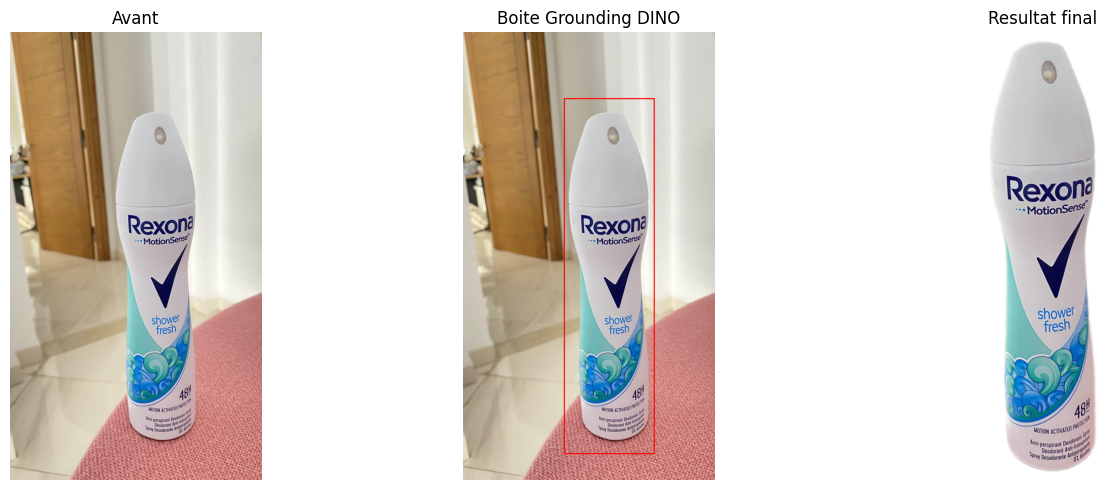

In [11]:
PROBLEM_IMAGE = image_paths[0]  # <-- remplace par le chemin exact de l'image qui gardait la main
img = Image.open(PROBLEM_IMAGE).convert("RGB")

box = detect_product_box(img)
print("Boite detectee (produit uniquement) :", box)

cutout, mask = remove_background(img)
cutout = crop_to_content(cutout)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img); axes[0].set_title("Avant"); axes[0].axis("off")
if box is not None:
    img_box = img.copy()
    ImageDraw.Draw(img_box).rectangle(box, outline="red", width=4)
    axes[1].imshow(img_box); axes[1].set_title("Boite Grounding DINO"); axes[1].axis("off")
else:
    axes[1].imshow(img); axes[1].set_title("Aucune boite -- fallback BiRefNet"); axes[1].axis("off")
axes[2].imshow(cutout); axes[2].set_title("Resultat final"); axes[2].axis("off")
plt.tight_layout()
plt.show()


In [12]:
# Si besoin d'un prompt/threshold different pour certaines images specifiques
PER_IMAGE_OVERRIDES = {
    # "nom_de_fichier_sans_extension": {"text_prompt": "perfume bottle with gold cap.", "box_threshold": 0.2},
}
print(f"{len(PER_IMAGE_OVERRIDES)} overrides configures")


0 overrides configures


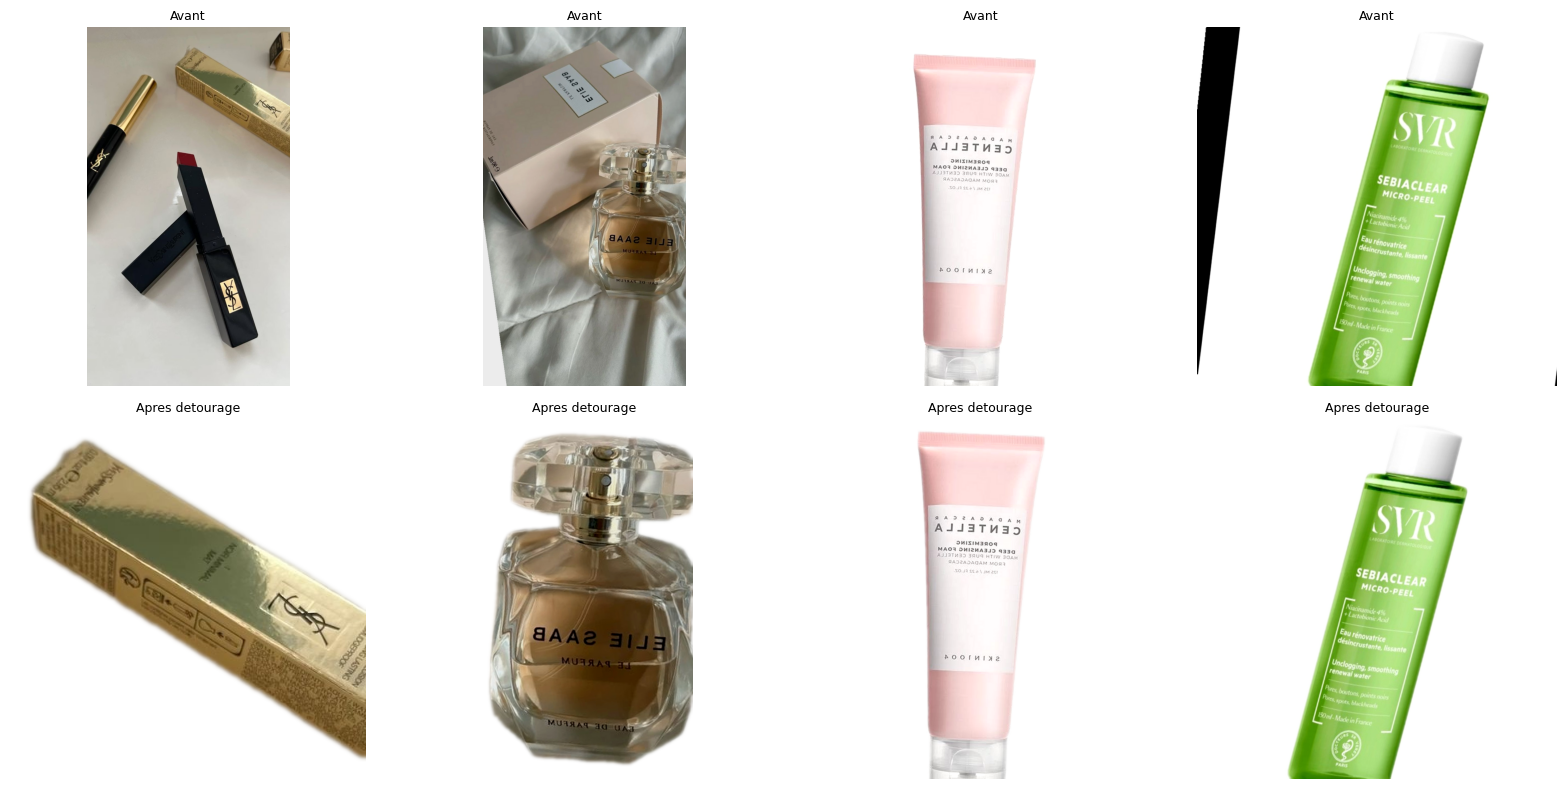

In [13]:
# Test visuel sur quelques echantillons avant de lancer sur les 600 images
test_samples = random.sample(image_paths, min(4, len(image_paths)))
fig, axes = plt.subplots(2, len(test_samples), figsize=(16, 8))
for i, p in enumerate(test_samples):
    img = Image.open(p).convert("RGB")
    cutout, mask = remove_background(img)
    cutout = crop_to_content(cutout)
    axes[0, i].imshow(img); axes[0, i].set_title("Avant", fontsize=9); axes[0, i].axis("off")
    axes[1, i].imshow(cutout); axes[1, i].set_title("Apres detourage", fontsize=9); axes[1, i].axis("off")
plt.tight_layout()
plt.show()


**Checkpoint qualité avant de continuer :** regarde les résultats ci-dessus.
- Le produit doit être seul, sans main ni fond, avec des bords propres.
- Si un cas précis résiste (main qui recouvre >50% du produit, boîte mal détectée) → ajuste `PER_IMAGE_OVERRIDES` ci-dessus avec un prompt plus spécifique pour ce fichier, ou vérifie visuellement avec la cellule "Outil de réglage".

**⚠️ Si tu as déjà lancé une version précédente de ce notebook (BiRefNet seul, sans Grounding DINO/SAM) :** ton checkpoint contient des entrées "terminées" faites avec l'ancienne méthode, qui gardait la main. Exécute la cellule de reset ci-dessous **une seule fois** avant de relancer le traitement complet, sinon ces images seront sautées et resteront mauvaises.


In [14]:
# RESET -- a executer UNE SEULE FOIS si tu as deja des cutouts/checkpoint issus
# d'une version precedente (BiRefNet seul, sans Grounding DINO + SAM).
# Sans risque : rien n'est supprime, tout est renomme en .old_backup au cas ou.

import shutil

old_checkpoint = os.path.join(WORK_DIR, "checkpoint_step1_detourage.json")
if os.path.exists(old_checkpoint):
    backup_path = old_checkpoint + ".old_birefnet_backup"
    if not os.path.exists(backup_path):
        shutil.move(old_checkpoint, backup_path)
        print("Ancien checkpoint (methode BiRefNet seule) sauvegarde ->", backup_path)
    else:
        print("Un backup existe deja, checkpoint actuel laisse tel quel.")

for dir_path in [CUTOUTS_DIR, MASKS_DIR]:
    if os.path.isdir(dir_path) and len(os.listdir(dir_path)) > 0:
        backup_dir = dir_path + "_old_birefnet_backup"
        if not os.path.exists(backup_dir):
            shutil.move(dir_path, backup_dir)
            os.makedirs(dir_path, exist_ok=True)
            print(f"{dir_path} (contenu ancien) sauvegarde -> {backup_dir}, dossier vide recree")
        else:
            print(f"Un backup existe deja pour {dir_path}, laisse tel quel.")

print("\\nReset termine -- la prochaine execution de la boucle de detourage va TOUT retraiter avec Grounding DINO + SAM.")


Un backup existe deja, checkpoint actuel laisse tel quel.
Un backup existe deja pour /content/drive/MyDrive/Stage_1_ouvrier/data/processed/cutouts, laisse tel quel.
Un backup existe deja pour /content/drive/MyDrive/Stage_1_ouvrier/data/processed/masks, laisse tel quel.
\nReset termine -- la prochaine execution de la boucle de detourage va TOUT retraiter avec Grounding DINO + SAM.


In [16]:
valid_stems = {Path(p).stem for p in image_paths}
print(f"Dataset actuel : {len(valid_stems)} images de reference")

def sync_dir_to_dataset(dir_path, valid_stems, label):
    if not os.path.isdir(dir_path):
        return 0, 0
    orphan_dir = dir_path + "_orphans_backup"
    moved = 0
    kept = 0
    for f in glob.glob(os.path.join(dir_path, "*.png")):
        stem = Path(f).stem
        if stem in valid_stems:
            kept += 1
        else:
            os.makedirs(orphan_dir, exist_ok=True)
            shutil.move(f, os.path.join(orphan_dir, os.path.basename(f)))
            moved += 1
    print(f"[{label}] {kept} fichiers valides conserves, {moved} orphelins deplaces -> {orphan_dir}" if moved else f"[{label}] {kept} fichiers valides, rien a nettoyer")
    return kept, moved

sync_dir_to_dataset(CUTOUTS_DIR, valid_stems, "cutouts")
sync_dir_to_dataset(MASKS_DIR, valid_stems, "masks")

CHECKPOINT_STEP1 = os.path.join(WORK_DIR, "checkpoint_step1_detourage.json")
really_done = set()
for stem in valid_stems:
    cutout_ok = os.path.exists(os.path.join(CUTOUTS_DIR, f"{stem}.png"))
    mask_ok = os.path.exists(os.path.join(MASKS_DIR, f"{stem}.png"))
    if cutout_ok and mask_ok:
        really_done.add(stem)

if os.path.exists(CHECKPOINT_STEP1):
    old_count = len(load_checkpoint(CHECKPOINT_STEP1))
    shutil.move(CHECKPOINT_STEP1, CHECKPOINT_STEP1 + ".pre_sync_backup")
    print(f"Ancien checkpoint ({old_count} entrees) sauvegarde")

save_checkpoint(CHECKPOINT_STEP1, really_done)
print(f"Checkpoint resynchronise : {len(really_done)}/{len(valid_stems)} images deja traitees")
print(f"Reste a traiter : {len(valid_stems) - len(really_done)}")

Dataset actuel : 600 images de reference
[cutouts] 384 fichiers valides conserves, 630 orphelins deplaces -> /content/drive/MyDrive/Stage_1_ouvrier/data/processed/cutouts_orphans_backup
[masks] 384 fichiers valides conserves, 630 orphelins deplaces -> /content/drive/MyDrive/Stage_1_ouvrier/data/processed/masks_orphans_backup
Ancien checkpoint (738 entrees) sauvegarde
Checkpoint resynchronise : 384/600 images deja traitees
Reste a traiter : 216


In [17]:
# Traitement complet du dataset (600 images) -- resumable via checkpoint
# Si la session coupe en cours de route (ou si tu changes de compte GPU), reexecute
# simplement cette cellule (apres avoir remonte le Drive + recharge les 3 modeles) :
# elle sautera automatiquement tout ce qui est deja fait.

CHECKPOINT_STEP1 = os.path.join(WORK_DIR, "checkpoint_step1_detourage.json")

def process_one_image_step1(image_path):
    name = Path(image_path).stem
    img = Image.open(image_path).convert("RGB")

    override = PER_IMAGE_OVERRIDES.get(name, {})
    cutout, mask = remove_background(
        img,
        text_prompt=override.get("text_prompt", PRODUCT_TEXT_PROMPT),
        box_threshold=override.get("box_threshold", 0.3),
    )
    cutout = crop_to_content(cutout)

    cutout.save(os.path.join(CUTOUTS_DIR, f"{name}.png"))
    mask.save(os.path.join(MASKS_DIR, f"{name}.png"))

run_resumable_batch(
    items=image_paths,
    key_fn=lambda p: Path(p).stem,
    process_fn=process_one_image_step1,
    checkpoint_path=CHECKPOINT_STEP1,
    save_every=10,      # sauvegarde la progression toutes les 10 images (perte max en cas de coupure brutale)
    label="Detourage",
)


[Detourage] 384 deja traites (checkpoint trouve), 216 restants sur 600
[Detourage] checkpoint sauvegarde -- 394/600
[Detourage] checkpoint sauvegarde -- 404/600
[Detourage] checkpoint sauvegarde -- 414/600
[Detourage] checkpoint sauvegarde -- 424/600
[Detourage] checkpoint sauvegarde -- 434/600
[Detourage] checkpoint sauvegarde -- 444/600
[Detourage] checkpoint sauvegarde -- 454/600
[Detourage] checkpoint sauvegarde -- 464/600
[Detourage] checkpoint sauvegarde -- 474/600
[Detourage] checkpoint sauvegarde -- 484/600
[Detourage] checkpoint sauvegarde -- 494/600
[Detourage] checkpoint sauvegarde -- 504/600
[Detourage] checkpoint sauvegarde -- 514/600
[Detourage] checkpoint sauvegarde -- 524/600
[Detourage] checkpoint sauvegarde -- 534/600
[Detourage] checkpoint sauvegarde -- 544/600
[Detourage] checkpoint sauvegarde -- 554/600
[Detourage] checkpoint sauvegarde -- 564/600
[Detourage] checkpoint sauvegarde -- 574/600
[Detourage] checkpoint sauvegarde -- 584/600
[Detourage] checkpoint sauveg

In [18]:
# Reconstruit processed_meta.json a partir des fichiers reellement presents sur Drive
# (fiable meme si le traitement a ete interrompu et repris plusieurs fois / depuis plusieurs comptes)

processed_meta = []
for cutout_path in sorted(glob.glob(os.path.join(CUTOUTS_DIR, "*.png"))):
    name = Path(cutout_path).stem
    mask_path = os.path.join(MASKS_DIR, f"{name}.png")
    if os.path.exists(mask_path):
        processed_meta.append({"name": name, "cutout": cutout_path, "mask": mask_path})

with open(os.path.join(WORK_DIR, "cutouts_meta.json"), "w") as f:
    json.dump(processed_meta, f, indent=2)

print(f"{len(processed_meta)}/{len(image_paths)} produits detoures disponibles -> {CUTOUTS_DIR}")
if len(processed_meta) < len(image_paths):
    print("Traitement incomplet -- reexecute la cellule precedente pour continuer (elle reprendra automatiquement).")


600/600 produits detoures disponibles -> /content/drive/MyDrive/Stage_1_ouvrier/data/processed/cutouts


### 1-ter. BONUS — alternative RMBG-2.0 si le pipeline ci-dessus ne suffit pas sur certains produits

Ne lance cette cellule que si des cas précis restent problématiques. `RMBG-2.0` (BRIA AI) est parfois plus précis sur verre transparent/reflets forts, mais **nécessite une authentification** :

1. Va sur https://huggingface.co/briaai/RMBG-2.0, connecte-toi, clique **"Agree and access repository"**.
2. Crée un token sur https://huggingface.co/settings/tokens (lecture seule suffit).
3. Dans Colab : icône clé 🔑 dans la barre latérale gauche → **"Secrets"** → ajoute `HF_TOKEN` avec ta valeur, active "Notebook access".
4. Si tu bascules sur l'autre compte Gmail, **répète ces 3 étapes sur ce compte aussi** (le token Colab secret n'est pas partagé entre comptes) — encore une raison de privilégier le pipeline Grounding DINO + SAM par défaut, qui n'en a pas besoin.


In [19]:
# BONUS -- decommente pour essayer RMBG-2.0 en complement (necessite HF_TOKEN, voir ci-dessus)
from huggingface_hub import login
from google.colab import userdata
login(token=userdata.get('HH_TOKEN'))

from transformers import AutoModelForImageSegmentation
seg_model_rmbg = AutoModelForImageSegmentation.from_pretrained(
    "briaai/RMBG-2.0", trust_remote_code=True
    ).to(device).eval()
if device == "cuda":
  seg_model_rmbg.half()


config.json:   0%|          | 0.00/405 [00:00<?, ?B/s]

BiRefNet_config.py:   0%|          | 0.00/298 [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/briaai/RMBG-2.0:
- BiRefNet_config.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


birefnet.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/briaai/RMBG-2.0:
- birefnet.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


model.safetensors:   0%|          | 0.00/885M [00:00<?, ?B/s]

In [20]:
# Liberation memoire GPU avant l'etape suivante (SDXL)
del dino_model, sam_model, seg_model
torch.cuda.empty_cache()
import gc; gc.collect()
print("Memoire GPU liberee pour l'etape 2")


Memoire GPU liberee pour l'etape 2


## 2. Extraction de la palette de couleurs du produit

But : déduire automatiquement l'ambiance (pastel / vibrant / sombre / naturel) à partir des couleurs dominantes du produit, pour guider le prompt de génération du background — exactement le principe utilisé dans l'exemple SVR (tons crème/beige qui font écho au packaging).


In [21]:
from sklearn.cluster import KMeans

def extract_palette(rgba_image, n_colors=5):
    # Ne considere que les pixels du produit (alpha > 0)
    arr = np.array(rgba_image.convert("RGBA"))
    mask = arr[:, :, 3] > 10
    pixels = arr[mask][:, :3]
    if len(pixels) == 0:
        return [(200, 200, 200)], "neutral"

    # Sous-echantillonnage pour la vitesse
    if len(pixels) > 20000:
        idx = np.random.choice(len(pixels), 20000, replace=False)
        pixels = pixels[idx]

    kmeans = KMeans(n_clusters=n_colors, n_init=4, random_state=42).fit(pixels)
    colors = kmeans.cluster_centers_.astype(int)
    counts = np.bincount(kmeans.labels_)
    order = np.argsort(-counts)
    colors = [tuple(colors[i]) for i in order]

    # Heuristique de vibe a partir de la couleur dominante (HSV)
    dom = np.array(colors[0], dtype=np.uint8).reshape(1, 1, 3)
    hsv = cv2.cvtColor(dom, cv2.COLOR_RGB2HSV)[0, 0]
    h, s, v = int(hsv[0]), int(hsv[1]), int(hsv[2])
    if v < 80:
        vibe = "dark, moody, premium"
    elif s < 40 and v > 180:
        vibe = "soft pastel, minimal, clean"
    elif s > 150:
        vibe = "vibrant, bold, energetic"
    else:
        vibe = "natural, warm, organic"

    return colors, vibe


def palette_to_prompt_fragment(colors):
    # Transforme les couleurs RGB en descriptions textuelles pour le prompt SDXL
    def rgb_to_name(rgb):
        r, g, b = rgb
        if r > 200 and g > 190 and b > 170: return "cream"
        if r > 180 and g < 150 and b < 150: return "terracotta"
        if g > r and g > b: return "sage green"
        if b > r and b > g: return "soft blue"
        if r > 200 and g > 200 and b > 200: return "white"
        if r < 60 and g < 60 and b < 60: return "charcoal"
        return "neutral beige"
    names = list(dict.fromkeys(rgb_to_name(c) for c in colors[:3]))  # dedupe en gardant l'ordre
    return ", ".join(names)


Couleurs dominantes: [(np.int64(190), np.int64(181), np.int64(183)), (np.int64(205), np.int64(204), np.int64(207)), (np.int64(121), np.int64(170), np.int64(179)), (np.int64(28), np.int64(114), np.int64(165)), (np.int64(28), np.int64(25), np.int64(69))]
Vibe detectee: soft pastel, minimal, clean
Fragment de prompt: neutral beige, cream, soft blue


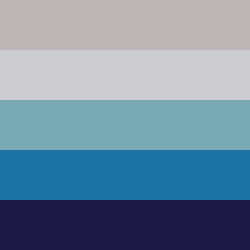

In [22]:
# Test sur un produit detoure
test_cutout = Image.open(processed_meta[0]["cutout"]).convert("RGBA")
colors, vibe = extract_palette(test_cutout)
frag = palette_to_prompt_fragment(colors)
print("Couleurs dominantes:", colors)
print("Vibe detectee:", vibe)
print("Fragment de prompt:", frag)

swatch = Image.new("RGB", (250, 50 * len(colors)))
d = ImageDraw.Draw(swatch)
for i, c in enumerate(colors):
    d.rectangle([0, i*50, 250, (i+1)*50], fill=tuple(c))
swatch


## 3. Génération du background — SDXL text2img + art-direction (catégorie/saison/palette)

### Diagnostic du bug "background noir/plat"

L'ancienne version plaçait le produit sur un **canvas transparent** (`Image.new("RGBA", ..., (0,0,0,0))`), puis appelait `.convert("RGB")` avant de l'envoyer à SDXL Inpainting. Problème : PIL ne compose **pas** le transparent sur du blanc lors d'un `.convert("RGB")` — il garde les valeurs RGB brutes sous-jacentes, qui valaient **(0,0,0) = noir**. Ce canvas majoritairement noir est ensuite utilisé comme **conditionnement direct du modèle** (`masked_image` — c'est ainsi que fonctionnent les modèles d'inpainting SD/SDXL : ils reçoivent l'image originale avec la zone à générer masquée, comme contexte). Résultat : le modèle recevait littéralement l'instruction visuelle *"complète autour d'un fond noir"*, peu importe le prompt texte. **C'est la cause exacte de tes backgrounds plats et sombres — pas un manque de puissance du modèle.**

### Pourquoi pas de fine-tuning ici

Un fine-tuning ou LoRA ne corrige pas ce genre de bug — il génère juste des variations autour du même défaut de conditionnement, en plus de coûter du temps de collecte/entraînement que tu n'as plus. SDXL de base est **largement capable** de produire des scènes du niveau de ton exemple "Velvet Crush" (marbre, tissu, fruits, bokeh doré) avec juste un bon prompt — c'est comme ça que ce type de visuel est produit dans l'industrie aujourd'hui. Le fine-tuning reste optionnel en bonus (section 3-bis) si tu veux un jour aller plus loin, mais **n'est pas le facteur qui bloquait tes résultats**.

### La correction : architecture text2img, pas inpainting

Au lieu d'inpainting (qui ancre la génération sur un canvas produit-en-place, biaisé par le bug ci-dessus), on **génère la scène complète d'abord** (SDXL text2img, aucune contrainte de canvas), **puis on compose le produit dessus** avec `harmonize_composite` (déjà dans le notebook, section 4 — ajustement de luminosité + ombre portée). Ça donne des scènes bien plus riches, car le modèle a une totale liberté créative au lieu d'essayer de "raccorder" une zone vide.

En plus : un système **catégorie + saison + palette** choisit automatiquement des accessoires de mise en scène adaptés (marbre, soie, fleurs, fruits, bokeh...) — le même principe que l'exemple Naturéa (aloe vera + argan en accessoires) ou Velvet Crush (pêche + fleurs de cerisier + soie orangée).


In [16]:
from diffusers import DiffusionPipeline, AutoencoderKL
import torch

# VAE corrige (evite les artefacts/NaN connus du VAE SDXL original en fp16)
fixed_vae = AutoencoderKL.from_pretrained("madebyollin/sdxl-vae-fp16-fix", torch_dtype=torch.float16)

sdxl_pipe = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    vae=fixed_vae,
    torch_dtype=torch.float16,
    variant="fp16",
).to(device)
sdxl_pipe.enable_model_cpu_offload()
sdxl_pipe.enable_vae_slicing()

print("SDXL text2img charge (VAE fp16-fix applique) sur", device)


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/631 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B /  335MB            

diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

...

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

NameError: name 'device' is not defined

In [24]:
import datetime

# --- Systeme d'art-direction : accessoires/matieres/lumiere par categorie de produit ---
CATEGORY_STYLES = {
    "perfume":     {"props": "faceted glass surfaces, silk fabric drapery, fresh flower petals, "
                              "citrus or stone fruit slices, warm golden hour lighting, soft bokeh sparkles",
                     "surface": "polished marble pedestal"},
    "face_care":   {"props": "natural stone surface, fresh green leaves, water droplets, "
                              "soft diffused daylight, minimal zen composition",
                     "surface": "matte stone or wood surface"},
    "body_care":   {"props": "linen fabric, botanical leaves, soft natural light, "
                              "calm spa atmosphere",
                     "surface": "light wood or travertine surface"},
    "hair_care":   {"props": "flowing silk fabric, natural fiber textures, warm directional light, "
                              "soft shadows",
                     "surface": "warm wood surface"},
    "makeup":      {"props": "glossy reflective surface, bold color accents, dramatic spot lighting, "
                              "subtle glitter particles",
                     "surface": "glossy black or acrylic surface"},
    "sun_care":    {"props": "sand texture, palm leaves, bright sunlight, turquoise water reflections",
                     "surface": "light sand or driftwood surface"},
    "hygiene_deo": {"props": "clean minimal studio, fresh mint or eucalyptus leaves, light water splash",
                     "surface": "white or pastel matte surface"},
    "generic":     {"props": "elegant minimal props, soft studio lighting, subtle shadow",
                     "surface": "polished marble pedestal"},
}

SEASON_STYLES = {
    "spring": "fresh blossoms, pastel tones, soft morning light",
    "summer": "vivid natural light, ripe fruit accents, vibrant colors",
    "autumn": "warm golden light, dried leaves, amber tones",
    "winter": "cool soft light, frosted textures, evergreen sprigs",
}

def detect_category(product_category_hint):
    hint = product_category_hint.lower()
    keyword_map = {
        "perfume": ["perfume", "parfum", "fragrance", "body mist", "eau de"],
        "face_care": ["face", "visage", "cream", "creme", "serum"],
        "body_care": ["body", "corps", "lotion", "baume", "balm"],
        "hair_care": ["hair", "cheveux", "shampoo", "shampooing", "conditioner"],
        "makeup": ["makeup", "maquillage", "lipstick", "foundation", "mascara"],
        "sun_care": ["sun", "solaire", "spf", "sunscreen"],
        "hygiene_deo": ["deo", "deodorant", "hygiene", "soap", "savon"],
    }
    for category, keywords in keyword_map.items():
        if any(kw in hint for kw in keywords):
            return category
    return "generic"


def pick_season(season="auto"):
    if season in SEASON_STYLES:
        return season
    month = datetime.datetime.now().month
    if month in (3, 4, 5): return "spring"
    if month in (6, 7, 8): return "summer"
    if month in (9, 10, 11): return "autumn"
    return "winter"


In [25]:
NEGATIVE_PROMPT = (
    "text, watermark, logo, blurry, low quality, distorted, extra objects, "
    "hands, fingers, people, clutter, low resolution, deformed, flat lighting, "
    "plain background, empty background, dark, underexposed, boring"
)

def build_background_prompt(vibe, palette_fragment, product_category="generic", season="auto"):
    category = detect_category(product_category)
    style = CATEGORY_STYLES[category]
    season_resolved = pick_season(season)
    season_accent = SEASON_STYLES[season_resolved]

    return (
        f"professional editorial product photography set, commercial advertising campaign, "
        f"{style['surface']}, {style['props']}, {season_accent}, "
        f"{palette_fragment} color palette, {vibe} atmosphere, "
        f"shallow depth of field, soft bokeh background, cinematic lighting, "
        f"ultra detailed, 8k, photorealistic, award winning advertising photography"
    ), category, season_resolved


def place_product_on_canvas(rgba_cutout, canvas_size=1024, margin_ratio=0.55):
    # Positionne le produit sur un canvas transparent (regle des tiers) -- utilise
    # APRES generation du background, pour la composition (pas pour l'inpainting)
    canvas = Image.new("RGBA", (canvas_size, canvas_size), (0, 0, 0, 0))
    w, h = rgba_cutout.size
    max_dim = int(canvas_size * margin_ratio)
    scale = max_dim / max(w, h)
    new_size = (int(w * scale), int(h * scale))
    resized = rgba_cutout.resize(new_size, Image.LANCZOS)
    x = (canvas_size - new_size[0]) // 2
    y = int(canvas_size * 0.62) - new_size[1] // 2
    canvas.paste(resized, (x, y), resized)
    return canvas


In [26]:
def generate_background(rgba_cutout, vibe, palette_fragment, product_category="generic", season="auto",
                          canvas_size=1024, steps=35, guidance=8.5, seed=None):
    # Genere la scene complete en texte->image (liberte totale, pas de canvas noir biaisant),
    # puis positionne le produit dessus -- compatible avec harmonize_composite (section 4)
    prompt, resolved_category, resolved_season = build_background_prompt(vibe, palette_fragment, product_category, season)
    generator = torch.Generator(device=device).manual_seed(seed) if seed is not None else None

    background = sdxl_pipe(
        prompt=prompt,
        negative_prompt=NEGATIVE_PROMPT,
        height=canvas_size,
        width=canvas_size,
        num_inference_steps=steps,
        guidance_scale=guidance,
        generator=generator,
    ).images[0]

    canvas_rgba = place_product_on_canvas(rgba_cutout, canvas_size)
    return background, canvas_rgba, prompt


Token indices sequence length is longer than the specified maximum sequence length for this model (83 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['realistic, award winning advertising photography']
Token indices sequence length is longer than the specified maximum sequence length for this model (83 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['realistic, award winning advertising photography']


  0%|          | 0/35 [00:00<?, ?it/s]

Prompt utilise: professional editorial product photography set, commercial advertising campaign, polished marble pedestal, elegant minimal props, soft studio lighting, subtle shadow, vivid natural light, ripe fruit accents, vibrant colors, neutral beige, cream, soft blue color palette, soft pastel, minimal, clean atmosphere, shallow depth of field, soft bokeh background, cinematic lighting, ultra detailed, 8k, photorealistic, award winning advertising photography


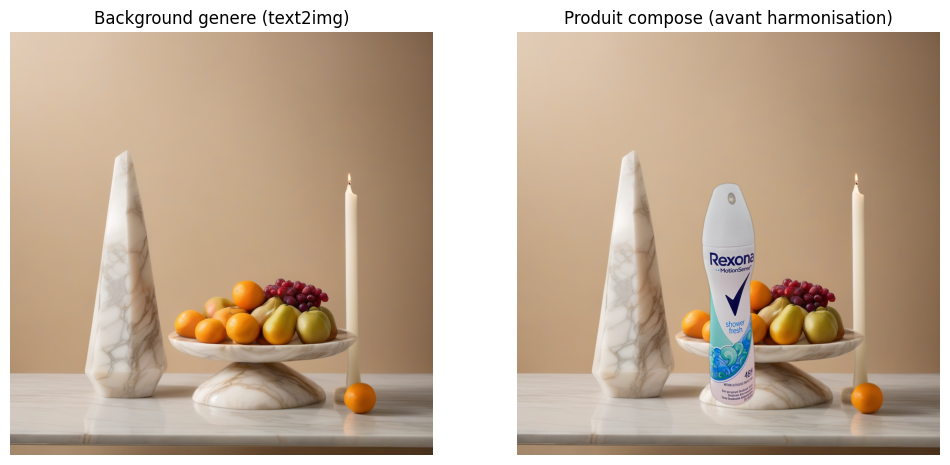

In [27]:
# Test sur un produit -- categorie/saison auto-detectees, remplace product_category
# par un indice explicite si tu connais deja le type de produit (ex: "perfume", "face_care"...)
colors, vibe = extract_palette(test_cutout)
frag = palette_to_prompt_fragment(colors)
bg_result, canvas_rgba, used_prompt = generate_background(
    test_cutout, vibe, frag, product_category="generic", season="auto", seed=42
)

print("Prompt utilise:", used_prompt)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(bg_result); axes[0].set_title("Background genere (text2img)"); axes[0].axis("off")
axes[1].imshow(Image.alpha_composite(bg_result.convert("RGBA"), canvas_rgba)); axes[1].set_title("Produit compose (avant harmonisation)"); axes[1].axis("off")
plt.show()


**Checkpoint qualité :** le background doit maintenant montrer une vraie scène (accessoires, profondeur, lumière), pas un aplat de couleur. Si le résultat reste trop simple :
- Augmente `guidance` (ex: 9-10) pour un suivi plus strict du prompt.
- Précise `product_category` explicitement au lieu de laisser `"generic"`.
- Ajoute des mots-clés spécifiques à ta marque dans `CATEGORY_STYLES` (ex: couleurs de marque, matières précises).


### 3-bis. BONUS — LoRA de style (à tenter seulement si le temps le permet)

Nécessite un petit set (30-100 images) de **backgrounds/affiches cibles** avec leurs captions — pas tes 600 photos brutes. Si tu n'as pas ce set curaté, **ignore cette section**, le prompt engineering ci-dessus est déjà une solution solide et livrable.


In [3]:
import os

In [6]:
with open(os.path.join(WORK_DIR, "cutouts_meta.json")) as f:
    processed_meta = json.load(f)
test_cutout = Image.open(processed_meta[0]["cutout"]).convert("RGBA")

In [7]:
def generate_ad_copy(product_name, key_benefits, brand="", category_hint=""):
    if LLM_AVAILABLE:
        try:
            prompt = (
                f"Tu es un copywriter publicitaire cosmetique. Produit: {product_name} "
                f"(marque: {brand}, categorie: {category_hint}). "
                f"Benefices cles fournis: {', '.join(key_benefits)}. "
                f"Genere un JSON strict avec les cles :\n"
                f"headline (accroche courte, max 6 mots),\n"
                f"subheadline (max 12 mots),\n"
                f"tagline (phrase courte de marque, ex: 'La nature au service de votre beaute'),\n"
                f"benefits (liste de 3-4 objets {{icon, title, description}} ; icon doit etre "
                f"UN mot-cle parmi: shield, drop, clock, leaf, heart, sparkle, water, sun, moon, check),\n"
                f"badges (liste de 2-4 courtes certifications, ex: 'Cruelty free', 'Sans parabenes', "
                f"'Teste dermatologiquement', '100% naturel' -- choisis celles pertinentes pour ce produit),\n"
                f"cta (max 4 mots).\n"
                f"Reponds uniquement en JSON, rien d'autre."
            )
            messages = [{"role": "user", "content": prompt}]
            inputs = llm_tokenizer.apply_chat_template(messages, return_tensors="pt").to(llm_model.device)
            out = llm_model.generate(inputs, max_new_tokens=400, temperature=0.7, do_sample=True)
            text = llm_tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)
            json_start = text.find("{")
            json_end = text.rfind("}") + 1
            parsed = json.loads(text[json_start:json_end])
            # garde-fous : si le LLM oublie un champ, on complete avec le fallback
            parsed.setdefault("benefits", _fallback_benefits(key_benefits))
            parsed.setdefault("badges", ["Qualite premium"])
            return parsed
        except Exception as e:
            print("Generation LLM echouee, fallback template:", e)

    tpl = random.choice(AD_COPY_TEMPLATES)
    return {
        "headline": tpl["headline"].format(product=product_name),
        "subheadline": tpl["sub"],
        "tagline": "",
        "benefits": _fallback_benefits(key_benefits),
        "badges": ["Qualite premium"],
        "cta": "En savoir plus",
    }

def _fallback_benefits(key_benefits, icons_cycle=("shield", "drop", "clock", "leaf")):
    return [
        {"icon": icons_cycle[i % len(icons_cycle)], "title": b.split(",")[0][:28], "description": b}
        for i, b in enumerate(key_benefits[:4])
    ]

In [8]:
def draw_icon(draw_ctx, icon_name, cx, cy, size, color):
    r = size // 2
    if icon_name == "shield":
        draw_ctx.polygon([(cx, cy-r), (cx+r, cy-r*0.4), (cx+r*0.6, cy+r), (cx, cy+r*0.8),
                           (cx-r*0.6, cy+r), (cx-r, cy-r*0.4)], outline=color, width=3)
    elif icon_name == "drop":
        draw_ctx.pieslice([cx-r, cy-r*0.2, cx+r, cy+r*1.2], 0, 360, outline=color, width=3)
        draw_ctx.polygon([(cx, cy-r*1.3), (cx-r*0.6, cy-r*0.1), (cx+r*0.6, cy-r*0.1)], outline=color, width=3)
    elif icon_name == "clock":
        draw_ctx.ellipse([cx-r, cy-r, cx+r, cy+r], outline=color, width=3)
        draw_ctx.line([cx, cy, cx, cy-r*0.6], fill=color, width=3)
        draw_ctx.line([cx, cy, cx+r*0.4, cy], fill=color, width=3)
    elif icon_name == "leaf":
        draw_ctx.arc([cx-r, cy-r, cx+r, cy+r], 200, 20, fill=color, width=3)
        draw_ctx.line([cx-r*0.7, cy+r*0.5, cx+r*0.7, cy-r*0.5], fill=color, width=3)
    elif icon_name == "heart":
        draw_ctx.pieslice([cx-r, cy-r*0.6, cx, cy+r*0.4], 180, 360, outline=color, width=3)
        draw_ctx.pieslice([cx, cy-r*0.6, cx+r, cy+r*0.4], 180, 360, outline=color, width=3)
        draw_ctx.polygon([(cx-r, cy-r*0.1), (cx, cy+r), (cx+r, cy-r*0.1)], outline=color, width=3)
    elif icon_name in ("water", "sun", "moon", "sparkle"):
        draw_ctx.ellipse([cx-r, cy-r, cx+r, cy+r], outline=color, width=3)
    else:  # check / defaut
        draw_ctx.line([cx-r*0.6, cy, cx-r*0.1, cy+r*0.5], fill=color, width=4)
        draw_ctx.line([cx-r*0.1, cy+r*0.5, cx+r*0.6, cy-r*0.5], fill=color, width=4)

In [9]:
BRAND_PALETTES = {
    # accent, texte principal — adapte/ajoute selon la vibe detectee si tu veux un mapping auto
    "warm": ((214, 122, 47), (30, 30, 30)),
    "soft pastel, minimal, clean": ((201, 140, 160), (60, 40, 50)),
    "dark, moody, premium": ((180, 150, 90), (20, 20, 20)),
    "vibrant, bold, energetic": ((214, 40, 110), (20, 20, 20)),
    "natural, warm, organic": ((90, 120, 70), (30, 30, 30)),
}

def compose_poster(harmonized_bg, ad_copy, brand="", format_name="instagram", vibe="natural, warm, organic"):
    size = POSTER_FORMATS[format_name]
    accent, text_color = BRAND_PALETTES.get(vibe, BRAND_PALETTES["natural, warm, organic"])
    poster = harmonized_bg.resize(size, Image.LANCZOS).convert("RGB")
    draw = ImageDraw.Draw(poster)

    font_brand = ImageFont.truetype("/content/font_bold.ttf", int(size[0]*0.035))
    font_head  = ImageFont.truetype("/content/font_bold.ttf", int(size[0]*0.055))
    font_sub   = ImageFont.truetype("/content/font_regular.ttf", int(size[0]*0.024))
    font_tag   = ImageFont.truetype("/content/font_regular.ttf", int(size[0]*0.022))
    font_btitle= ImageFont.truetype("/content/font_bold.ttf", int(size[0]*0.02))
    font_bdesc = ImageFont.truetype("/content/font_regular.ttf", int(size[0]*0.016))
    font_badge = ImageFont.truetype("/content/font_regular.ttf", int(size[0]*0.014))

    pad = int(size[0]*0.045)
    y = pad

    if brand:
        draw.text((pad, y), brand.upper(), font=font_brand, fill=text_color)
        y += int(size[0]*0.05)

    draw.text((pad, y), ad_copy["headline"], font=font_head, fill=text_color)
    y += int(size[0]*0.07)
    if ad_copy.get("subheadline"):
        draw.text((pad, y), ad_copy["subheadline"], font=font_sub, fill=(90, 90, 90))
        y += int(size[0]*0.04)

    # liste de benefices avec icone
    icon_size = int(size[0]*0.03)
    for b in ad_copy.get("benefits", [])[:4]:
        y += int(size[0]*0.015)
        draw_icon(draw, b.get("icon", "check"), pad+icon_size, y+icon_size, icon_size, accent)
        tx = pad + icon_size*2 + 10
        draw.text((tx, y), b.get("title", ""), font=font_btitle, fill=text_color)
        draw.text((tx, y+int(size[0]*0.022)), b.get("description", ""), font=font_bdesc, fill=(100, 100, 100))
        y += int(size[0]*0.055)

    if ad_copy.get("tagline"):
        draw.text((pad, y), ad_copy["tagline"], font=font_tag, fill=accent)

    # bandeau de badges en bas
    band_h = int(size[1]*0.07)
    draw.rectangle([0, size[1]-band_h, size[0], size[1]], fill=accent)
    badges = ad_copy.get("badges", [])
    if badges:
        seg_w = size[0] / len(badges)
        for i, badge in enumerate(badges):
            tw = draw.textlength(badge, font=font_badge)
            tx = int(i*seg_w + (seg_w-tw)/2)
            draw.text((tx, size[1]-band_h+int(band_h*0.35)), badge, font=font_badge, fill=(255, 255, 255))

    return poster

In [12]:
!wget -q -O /content/font_bold.ttf https://raw.githubusercontent.com/google/fonts/main/ofl/poppins/Poppins-Bold.ttf
!wget -q -O /content/font_regular.ttf https://raw.githubusercontent.com/google/fonts/main/ofl/poppins/Poppins-Regular.ttf
print("Polices telechargees")

POSTER_FORMATS = {
    "instagram": (1080, 1080),
    "facebook": (1200, 630),
    "linkedin": (1200, 627),
}

Polices telechargees


In [13]:
posters = {fmt: compose_poster(harmonized, ad_copy, brand="SVR", format_name=fmt, vibe=vibe)
           for fmt in POSTER_FORMATS}

NameError: name 'harmonized' is not defined

In [11]:
# Ajoute des mots-cles marque -> categorie connus, en plus des mots-cles generiques existants
BRAND_CATEGORY_HINTS = {
    "rexona": "hygiene_deo", "nivea men": "hygiene_deo", "axe": "hygiene_deo",
    "sheglam": "makeup", "essence": "makeup", "maybelline": "makeup",
    "daylong": "sun_care", "la roche posay": "face_care", "svr": "body_care",
}

def detect_category(product_category_hint):
    hint = product_category_hint.lower()
    for brand_kw, cat in BRAND_CATEGORY_HINTS.items():
        if brand_kw in hint:
            return cat
    keyword_map = {
        "hygiene_deo": ["deo", "deodorant", "anti-transpirant", "antiperspirant", "hygiene", "soap", "savon"],
        # ... garde le reste de ton mapping existant
    }
    for category, keywords in keyword_map.items():
        if any(kw in hint for kw in keywords):
            return category
    return "generic"

In [14]:
!git clone https://github.com/huggingface/diffusers.git

!pip install -q -r diffusers/examples/text_to_image/requirements_sdxl.txt

!accelerate launch diffusers/examples/text_to_image/train_text_to_image_lora_sdxl.py \
  --pretrained_model_name_or_path="stabilityai/stable-diffusion-xl-base-1.0" \
  --train_data_dir="/content/drive/MyDrive/Stage_1_ouvrier/data/style_lora_dataset" \
  --resolution=1024 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --learning_rate=1e-4 \
  --lr_scheduler="cosine" \
  --lr_warmup_steps=0 \
  --rank=16 \
  --max_train_steps=2000 \
  --checkpointing_steps=500 \
  --mixed_precision="fp16" \
  --resume_from_checkpoint="latest" \
  --output_dir="/content/drive/MyDrive/Stage_1_ouvrier/models/style_lora"

Cloning into 'diffusers'...
remote: Enumerating objects: 129060, done.
remote: Counting objects: 100% (234/234), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 129060 (delta 161), reused 104 (delta 98), pack-reused 128826 (from 2)
Receiving objects: 100% (129060/129060), 102.71 MiB | 14.89 MiB/s, done.
Resolving deltas: 100% (96522/96522), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00
The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are 

In [15]:
# Liberation memoire GPU avant l'etape suivante (LLM texte)
del sdxl_pipe
torch.cuda.empty_cache()
import gc; gc.collect()
print("Memoire GPU liberee pour l'etape 4")


NameError: name 'sdxl_pipe' is not defined

## 4. Harmonisation produit / background

Un détourage + background généré séparément peut sembler "collé". Cette étape ajuste luminosité/contraste du produit pour matcher le fond, et ajoute une ombre portée douce réaliste — approche légère (Pillow/OpenCV), fiable et rapide, sans modèle supplémentaire.

*(Option plus poussée : IC-Light — `lllyasviel/IC-Light` — pour un relighting génératif complet. Mentionné ici comme piste d'amélioration future, non nécessaire pour un rendu déjà convaincant dans les 48h.)*


In [ ]:
def harmonize_composite(canvas_rgba, background_rgb, shadow_opacity=90, blur_radius=18):
    background_rgb = background_rgb.convert("RGB").resize(canvas_rgba.size)

    # 1) Ajustement leger de la luminosite du produit vers celle du fond
    bg_gray = np.array(background_rgb.convert("L"))
    product_alpha = np.array(canvas_rgba.split()[-1])
    bg_brightness = bg_gray[product_alpha < 10].mean() if (product_alpha < 10).any() else bg_gray.mean()

    product_rgb = canvas_rgba.convert("RGB")
    product_gray = np.array(product_rgb.convert("L"))
    product_brightness = product_gray[product_alpha > 10].mean() if (product_alpha > 10).any() else product_gray.mean()

    factor = np.clip(bg_brightness / max(product_brightness, 1), 0.85, 1.15)
    from PIL import ImageEnhance
    product_rgb = ImageEnhance.Brightness(product_rgb).enhance(float(factor))
    product_rgba = product_rgb.convert("RGBA")
    product_rgba.putalpha(canvas_rgba.split()[-1])

    # 2) Ombre portee douce sous le produit
    alpha_mask = product_rgba.split()[-1]
    shadow = Image.new("RGBA", canvas_rgba.size, (0, 0, 0, 0))
    shadow_shape = Image.new("L", canvas_rgba.size, 0)
    shadow_shape.paste(alpha_mask, (0, 10))  # decalage vertical leger
    shadow.putalpha(shadow_shape.point(lambda a: int(a * (shadow_opacity / 255))))
    shadow = shadow.filter(ImageFilter.GaussianBlur(blur_radius))

    # 3) Composition finale : fond -> ombre -> produit
    final = background_rgb.convert("RGBA")
    final = Image.alpha_composite(final, shadow)
    final = Image.alpha_composite(final, product_rgba)
    return final.convert("RGB")


In [ ]:
harmonized = harmonize_composite(canvas_rgba, bg_result)
harmonized


## 5. Génération du texte publicitaire

Approche avec **fallback automatique** : tentative avec un LLM open source public (**Qwen2.5-7B-Instruct**, 4-bit, aucune authentification requise) ; si la mémoire GPU manque ou le chargement échoue, bascule vers un générateur par templates (garantit qu'il y a toujours un texte, jamais de crash en pleine démo).

*(Note : `Mistral-7B-Instruct` est **gated** sur Hugging Face — licence à accepter + token requis, même friction que RMBG-2.0. Qwen2.5-7B-Instruct est public, évite complètement ce problème, d'où le choix par défaut.)*


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

LLM_AVAILABLE = True
try:
    bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
    llm_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B-Instruct")
    llm_model = AutoModelForCausalLM.from_pretrained(
        "Qwen/Qwen2.5-7B-Instruct",
        quantization_config=bnb_config,
        device_map="auto",
    )
    print("LLM charge en 4-bit")
except Exception as e:
    print("LLM indisponible, fallback template active. Raison:", e)
    LLM_AVAILABLE = False


In [ ]:
AD_COPY_TEMPLATES = [
    {"headline": "{product} — pense a chaque detail", "sub": "Une formule concue pour votre quotidien."},
    {"headline": "Decouvrez {product}", "sub": "L'allie de votre routine, jour apres jour."},
    {"headline": "{product} : simple, efficace, essentiel", "sub": "Le geste qui change tout."},
]

def generate_ad_copy(product_name, key_benefits, brand=""):
    # key_benefits : liste de courtes phrases (ex: ["repare et apaise 48h", "sans parfum"])
    if LLM_AVAILABLE:
        try:
            prompt = (
                f"Tu es un copywriter publicitaire. Produit: {product_name} (marque: {brand}). "
                f"Benefices cles: {', '.join(key_benefits)}. "
                f"Genere en JSON strict avec les cles headline (accroche courte, max 6 mots), "
                f"subheadline (max 10 mots), cta (max 4 mots). Reponds uniquement en JSON."
            )
            messages = [{"role": "user", "content": prompt}]
            inputs = llm_tokenizer.apply_chat_template(messages, return_tensors="pt").to(llm_model.device)
            out = llm_model.generate(inputs, max_new_tokens=150, temperature=0.7, do_sample=True)
            text = llm_tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)
            json_start = text.find("{")
            json_end = text.rfind("}") + 1
            parsed = json.loads(text[json_start:json_end])
            return parsed
        except Exception as e:
            print("Generation LLM echouee, fallback template:", e)

    tpl = random.choice(AD_COPY_TEMPLATES)
    return {
        "headline": tpl["headline"].format(product=product_name),
        "subheadline": tpl["sub"],
        "cta": "En savoir plus",
    }


In [ ]:
ad_copy = generate_ad_copy(
    product_name="Baume Protect+ Topialyse",
    key_benefits=["repare et apaise en 48h", "anti-demangeaisons", "sans parfum, ne pique pas"],
    brand="SVR",
)
print(json.dumps(ad_copy, indent=2, ensure_ascii=False))


In [ ]:
# Liberation memoire GPU (fin des etapes generatives)
if LLM_AVAILABLE:
    del llm_model
torch.cuda.empty_cache()
import gc; gc.collect()
print("Memoire GPU liberee pour la composition finale")


## 6. Composition des affiches — Instagram / Facebook / LinkedIn

Génération de texte fiable via diffusion = mauvaise idée (texte souvent illisible/halluciné). On compose donc le texte en overlay avec **Pillow**, sur 3 formats, à partir d'un template configurable — rapide, net, contrôlable.


In [ ]:
!wget -q -O /content/font_bold.ttf https://raw.githubusercontent.com/google/fonts/main/ofl/poppins/Poppins-Bold.ttf
!wget -q -O /content/font_regular.ttf https://raw.githubusercontent.com/google/fonts/main/ofl/poppins/Poppins-Regular.ttf
print("Polices telechargees")


In [ ]:
POSTER_FORMATS = {
    "instagram": (1080, 1080),
    "facebook": (1200, 630),
    "linkedin": (1200, 627),
}

def compose_poster(harmonized_bg, ad_copy, brand="", format_name="instagram", accent_color=(200, 90, 90)):
    size = POSTER_FORMATS[format_name]
    poster = harmonized_bg.resize(size, Image.LANCZOS).convert("RGB")

    # Bandeau semi-transparent en bas pour la lisibilite du texte
    overlay = Image.new("RGBA", size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)
    band_height = int(size[1] * 0.28)
    draw.rectangle([0, size[1] - band_height, size[0], size[1]], fill=(255, 255, 255, 235))

    poster = Image.alpha_composite(poster.convert("RGBA"), overlay).convert("RGB")
    draw = ImageDraw.Draw(poster)

    font_head = ImageFont.truetype("/content/font_bold.ttf", int(size[0] * 0.045))
    font_sub = ImageFont.truetype("/content/font_regular.ttf", int(size[0] * 0.025))
    font_cta = ImageFont.truetype("/content/font_bold.ttf", int(size[0] * 0.022))
    font_brand = ImageFont.truetype("/content/font_bold.ttf", int(size[0] * 0.03))

    pad = int(size[0] * 0.05)
    y = size[1] - band_height + pad

    if brand:
        draw.text((pad, y), brand.upper(), font=font_brand, fill=(60, 60, 60))
        y += int(size[0] * 0.05)

    draw.text((pad, y), ad_copy["headline"], font=font_head, fill=(20, 20, 20))
    y += int(size[0] * 0.06)
    draw.text((pad, y), ad_copy.get("subheadline", ""), font=font_sub, fill=(90, 90, 90))
    y += int(size[0] * 0.05)

    cta_text = ad_copy.get("cta", "En savoir plus")
    cta_w = draw.textlength(cta_text, font=font_cta) + 40
    draw.rounded_rectangle([pad, y, pad + cta_w, y + int(size[0]*0.045)], radius=8, fill=accent_color)
    draw.text((pad + 20, y + 8), cta_text, font=font_cta, fill=(255, 255, 255))

    return poster


In [ ]:
posters = {fmt: compose_poster(harmonized, ad_copy, brand="SVR", format_name=fmt) for fmt in POSTER_FORMATS}

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for ax, (fmt, img) in zip(axes, posters.items()):
    ax.imshow(img); ax.set_title(fmt); ax.axis("off")
plt.tight_layout()
plt.show()


## 7. Export ZIP (3 affiches + texte généré)

In [ ]:
def export_zip(posters, ad_copy, product_name, out_dir=ZIP_DIR):
    safe_name = "".join(c if c.isalnum() else "_" for c in product_name)[:50]
    product_dir = os.path.join(out_dir, safe_name)
    os.makedirs(product_dir, exist_ok=True)

    for fmt, img in posters.items():
        img.save(os.path.join(product_dir, f"{fmt}.png"))

    with open(os.path.join(product_dir, "ad_copy.json"), "w", encoding="utf-8") as f:
        json.dump(ad_copy, f, indent=2, ensure_ascii=False)

    zip_path = os.path.join(out_dir, f"{safe_name}.zip")
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for root, _, files in os.walk(product_dir):
            for file in files:
                fp = os.path.join(root, file)
                zf.write(fp, arcname=os.path.relpath(fp, product_dir))

    return zip_path

zip_path = export_zip(posters, ad_copy, "SVR_Baume_Protect_Topialyse")
print("ZIP genere:", zip_path)

from google.colab import files
files.download(zip_path)


## 8. Fonction pipeline complète (pour intégration backend)

Une seule fonction `process_product()` qui enchaîne toutes les étapes — c'est celle-ci que tu appelleras depuis ton endpoint FastAPI. **Important :** dans ton backend, charge `dino_model`, `sam_model`, `seg_model`, `sdxl_pipe`, `llm_model` **une seule fois au démarrage du serveur** (pas à chaque requête), sinon chaque appel prendra plusieurs minutes.


In [ ]:
def process_product(image_path_or_pil, product_name, key_benefits, brand="",
                     product_category="generic", season="auto", seed=None):
    # 1. Detourage
    img = image_path_or_pil if isinstance(image_path_or_pil, Image.Image) else Image.open(image_path_or_pil).convert("RGB")
    cutout, _ = remove_background(img)
    cutout = crop_to_content(cutout)

    # 2. Palette
    colors, vibe = extract_palette(cutout)
    frag = palette_to_prompt_fragment(colors)

    # 3. Background -- product_category peut etre "perfume", "face_care", "body_care",
    #    "hair_care", "makeup", "sun_care", "hygiene_deo", ou "generic" (auto-detecte sinon)
    bg_result, canvas_rgba, _ = generate_background(cutout, vibe, frag, product_category, season, seed=seed)

    # 4. Harmonisation
    harmonized = harmonize_composite(canvas_rgba, bg_result)

    # 5. Texte
    ad_copy = generate_ad_copy(product_name, key_benefits, brand)

    # 6. Composition
    posters = {fmt: compose_poster(harmonized, ad_copy, brand=brand, format_name=fmt) for fmt in POSTER_FORMATS}

    # 7. ZIP
    zip_path = export_zip(posters, ad_copy, product_name)
    return zip_path


## 9. Intégration dans ton backend FastAPI

```python
# Au demarrage du serveur (une seule fois) :
# seg_model, sdxl_pipe, llm_model/LLM_AVAILABLE sont charges globalement

@app.post("/generate-poster")
async def generate_poster(file: UploadFile, product_name: str, benefits: list[str], brand: str = ""):
    img = Image.open(io.BytesIO(await file.read())).convert("RGB")
    zip_path = process_product(img, product_name, benefits, brand)
    return FileResponse(zip_path, media_type="application/zip", filename=os.path.basename(zip_path))
```

**Points d'attention pour la mise en prod :**
- Un appel complet prend ~15-30s sur GPU dédié (T4/L4). Prévois une queue/job async si plusieurs utilisateurs simultanés.
- Garde les modèles en mémoire GPU en permanence (pas de chargement par requête).
- Si ton hébergement de prod n'a pas de GPU, prévois un fallback (endpoint séparé sur une instance GPU à la demande, ou service managé).


## ✅ Checklist 48h

1. [ ] Sections 0-1 : détourage validé visuellement sur 10-15 échantillons de ton dataset
2. [ ] Section 1 : traitement complet des 600 images (cutouts + masques sauvegardés)
3. [ ] Sections 2-3 : génération background testée sur 3-5 produits différents, prompts ajustés si besoin
4. [ ] Section 4 : harmonisation activée, rendu jugé "pas collé"
5. [ ] Section 5 : texte généré (LLM ou fallback template — les deux marchent, pas de blocage)
6. [ ] Section 6-7 : 3 formats corrects, ZIP téléchargeable
7. [ ] Section 8 : `process_product()` testée end-to-end sur un produit jamais vu
8. [ ] Section 9 : endpoint FastAPI branché, modèles chargés au démarrage (pas par requête)
9. [ ] BONUS (si temps restant) : LoRA de style, IC-Light, ControlNet depth
